# Detecting and Removing Outliers using boxplot 

In [ ]:
lst = [1,2,3,4,5]

In [ ]:
new_lst = []
for a in lst:
    new_lst.append(a*10)
new_lst

In [ ]:
import numpy as np
a = np.array(lst)
a*10

In [3]:
import pandas as pd

In [24]:
data  = pd.read_excel('emp.xlsx')
data

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.000000
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
3,3,1005,Manager,HR,45,120000.000000
4,4,2123,Office Boy,Accounts,27,45000.000000
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000


C:\Users\Administrator\anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


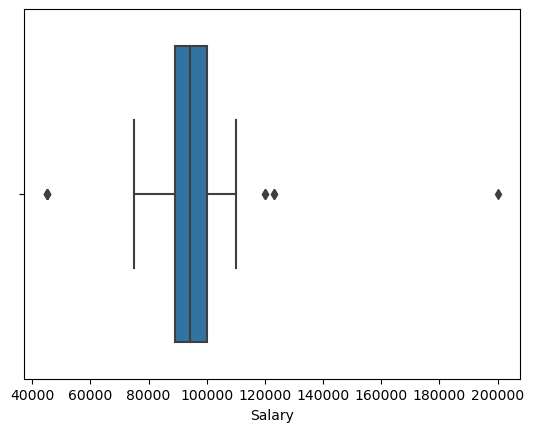

In [25]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.boxplot(data.Salary)
plt.show()

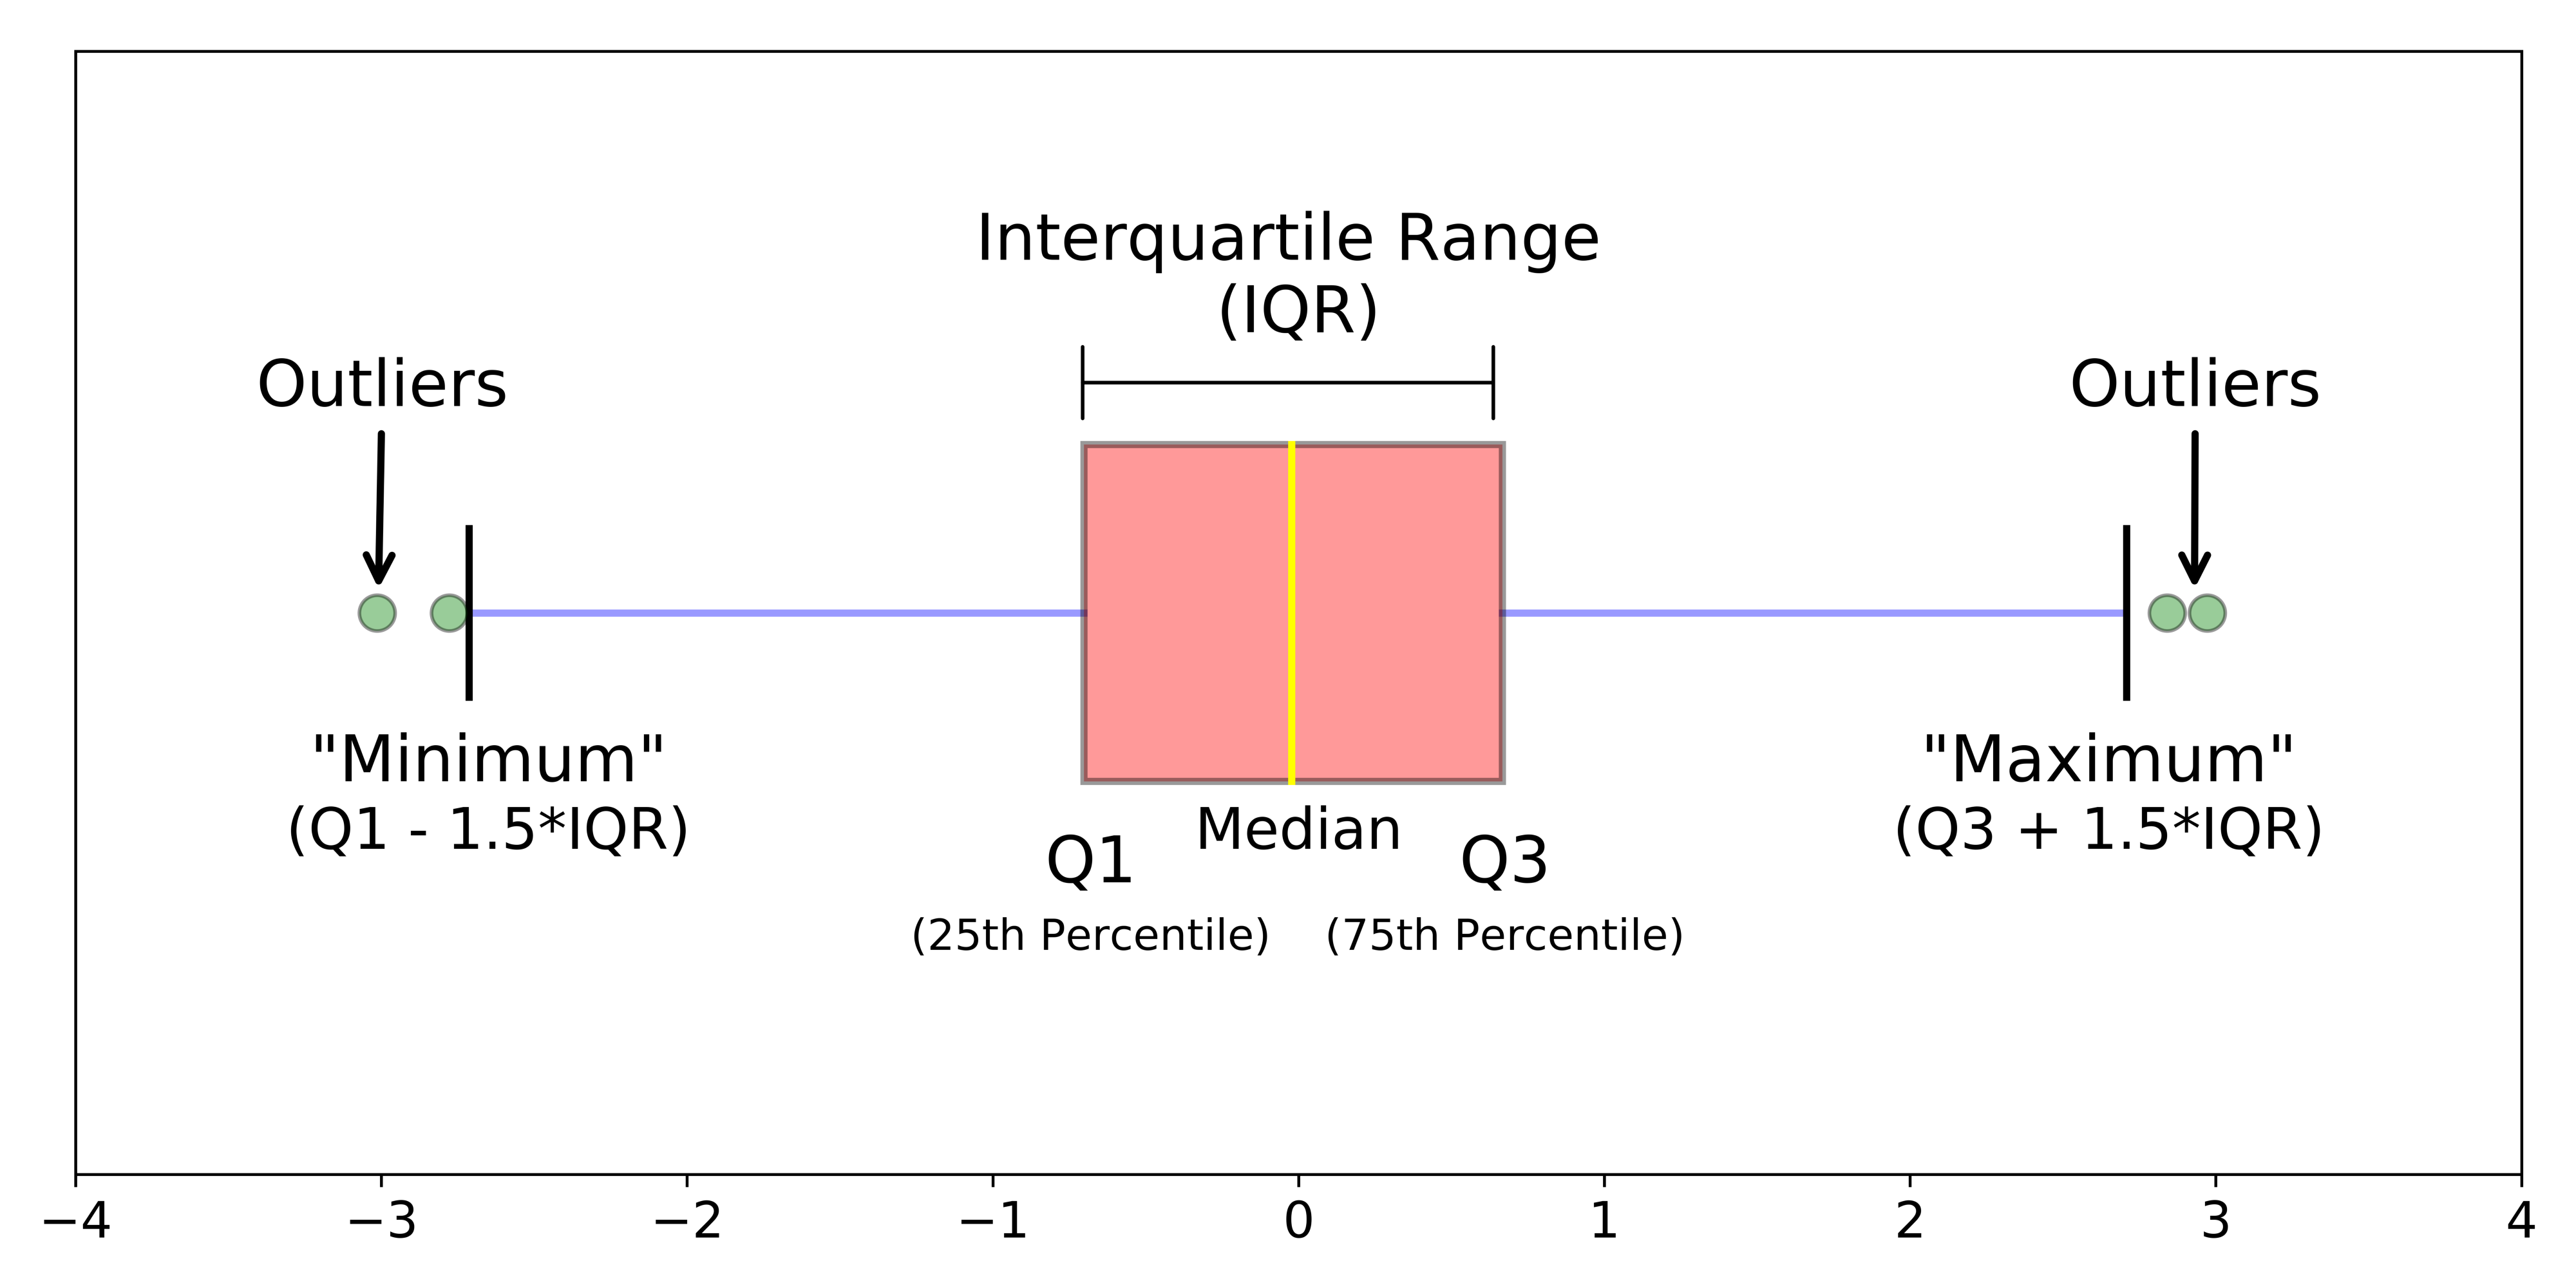

In [26]:
q1  = np.percentile(data.Salary,25)
q1

89000.0

In [27]:
q3 = np.percentile(data.Salary,75)
q3

100000.0

In [28]:
iqr = q3-q1
iqr

11000.0

In [29]:
min_salary  = q1-1.5*iqr
min_salary

72500.0

In [30]:
max_salary  = q3+1.5*iqr
max_salary

116500.0

In [31]:
data[(data.Salary<min_salary) | (data.Salary>max_salary)]

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.0
3,3,1005,Manager,HR,45,120000.0
4,4,2123,Office Boy,Accounts,27,45000.0
11,11,3214,Accountant,Account,49,123000.0
17,17,2123,Office Boy,Accounts,27,45000.0
18,18,1005,Manager,HR,45,120000.0
19,19,2123,Office Boy,Accounts,27,45000.0
21,21,3214,Accountant,Account,49,123000.0
25,25,2123,Office Boy,Accounts,27,45000.0


In [32]:
def detect_outliers(col):
    q1  = np.percentile(col,25)
    q3 = np.percentile(col,75)
    iqr = q3-q1
    lower_boundary= q1-1.5*iqr
    upper_boundary= q3+1.5*iqr
    return lower_boundary,upper_boundary

In [33]:
detect_outliers(data.Salary)

(72500.0, 116500.0)

In [34]:
data[(data.Salary<detect_outliers(data.Salary)[0]) | (data.Salary>detect_outliers(data.Salary)[1])]

,Serial,Emp_ID,Designation,Department,Age,Salary
0,0,1101,Manager,Accounts,50,200000.0
3,3,1005,Manager,HR,45,120000.0
4,4,2123,Office Boy,Accounts,27,45000.0
11,11,3214,Accountant,Account,49,123000.0
17,17,2123,Office Boy,Accounts,27,45000.0
18,18,1005,Manager,HR,45,120000.0
19,19,2123,Office Boy,Accounts,27,45000.0
21,21,3214,Accountant,Account,49,123000.0
25,25,2123,Office Boy,Accounts,27,45000.0


In [40]:
# outlier removed
data2 = data[(data.Salary>detect_outliers(data.Salary)[0]) & (data.Salary<detect_outliers(data.Salary)[1])]

In [41]:
data2

,Serial,Emp_ID,Designation,Department,Age,Salary
1,1,1107,Officer,IT,30,80000.000000
2,2,1203,Officer,HR,28,94173.913043
5,5,2451,Accountant,Production,34,100000.000000
6,6,1111,Accountant,Accounts,35,110000.000000
7,7,1001,Officer,IT,25,75000.000000
8,8,1234,Manager,IT,23,94173.913043
9,9,2156,Engineer,Production,45,89000.000000
10,10,6543,Officer,Production,29,100000.000000
12,12,2156,Engineer,Production,45,89000.000000
13,13,1098,Officer,IT,25,100000.000000


#### Duplicate Data Detection and Removal

In [47]:
data

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50,200000.000000
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
4,2123,Office Boy,Accounts,27,45000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000


In [45]:
data.drop('Serial',axis=1,inplace=True)

In [48]:
data[data.duplicated()]

,Emp_ID,Designation,Department,Age,Salary
12,2156,Engineer,Production,45,89000.0
16,2156,Engineer,Production,45,89000.0
17,2123,Office Boy,Accounts,27,45000.0
18,1005,Manager,HR,45,120000.0
19,2123,Office Boy,Accounts,27,45000.0
20,6543,Officer,Production,29,100000.0
21,3214,Accountant,Account,49,123000.0
22,2156,Engineer,Production,45,89000.0
23,1098,Officer,IT,25,100000.0
24,2156,Engineer,Production,45,89000.0


In [51]:
data[data.duplicated(subset=['Designation', 'Salary'])]

,Emp_ID,Designation,Department,Age,Salary
12,2156,Engineer,Production,45,89000.000000
13,1098,Officer,IT,25,100000.000000
15,1222,Officer,Production,25,94173.913043
16,2156,Engineer,Production,45,89000.000000
17,2123,Office Boy,Accounts,27,45000.000000
18,1005,Manager,HR,45,120000.000000
19,2123,Office Boy,Accounts,27,45000.000000
20,6543,Officer,Production,29,100000.000000
21,3214,Accountant,Account,49,123000.000000
22,2156,Engineer,Production,45,89000.000000


In [52]:
data.drop_duplicates(inplace=True)

In [54]:
# Duplicates Removed
data

,Emp_ID,Designation,Department,Age,Salary
0,1101,Manager,Accounts,50,200000.000000
1,1107,Officer,IT,30,80000.000000
2,1203,Officer,HR,28,94173.913043
3,1005,Manager,HR,45,120000.000000
4,2123,Office Boy,Accounts,27,45000.000000
5,2451,Accountant,Production,34,100000.000000
6,1111,Accountant,Accounts,35,110000.000000
7,1001,Officer,IT,25,75000.000000
8,1234,Manager,IT,23,94173.913043
9,2156,Engineer,Production,45,89000.000000


#### Transforming Data Using a Function or Mapping

In [55]:
emp  = pd.read_excel('employee.xlsx')

In [62]:
mapping = {'man':'Manager', 'off':'Officer','ofb':'Office Boy','acnt':'Accountant', 'eng':'Engineer'}

In [63]:
emp['full_designation'] = emp.Designation.map(mapping)

In [64]:
emp

,Serial,Emp_ID,Designation,Department,Age,Salary,full_designation
0,0,1101,man,Accounts,50.0,200000.0,Manager
1,1,1107,off,IT,30.0,80000.0,Officer
2,2,1203,off,HR,28.0,NaN,Officer
3,3,1005,man,HR,45.0,120000.0,Manager
4,4,2123,ofb,Accounts,27.0,45000.0,Office Boy
5,5,2451,acnt,NaN,34.0,100000.0,Accountant
6,6,1111,acnt,Accounts,NaN,110000.0,Accountant
7,7,1001,off,IT,25.0,75000.0,Officer
8,8,1234,man,IT,23.0,NaN,Manager
9,9,2156,eng,Production,45.0,89000.0,NaN
